In [1]:
import sys
from pathlib import Path
print(sys.executable)

C:\Users\Aryavart\stock-regime-ml\.venv\Scripts\python.exe


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from hmmlearn.hmm import GaussianHMM

PROJECT_ROOT = Path().resolve()
while not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))



from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from src.features import *
from src.volatility import *
from src.labeling import *

sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("../data/raw/nifty50.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

df = add_returns(df)
df = add_close_to_close_volatility(df, window=20)

df = df.dropna().reset_index(drop=True)

df.tail()

,Date,Open,High,Low,Close,Volume,return,vol_cc
4496,2026-02-13,25571.150391,25630.349609,25444.300781,25471.099609,453500,-0.013023,0.138191
4497,2026-02-16,25423.599609,25697.000000,25372.699219,25682.750000,275800,0.008309,0.141515
4498,2026-02-17,25637.949219,25764.400391,25570.300781,25725.400391,344100,0.001661,0.140728
4499,2026-02-18,25752.650391,25828.050781,25645.150391,25819.349609,310200,0.003652,0.130728
4500,2026-02-19,25873.349609,25885.300781,25388.750000,25454.349609,0,-0.014137,0.141139


# **Regime feature matrix**

In [4]:
regime_cols = ["return", "vol_cc"]

X_regime = df[regime_cols].values

# **Fit Gaussian HMM**

In [5]:
hmm = GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=500,
    random_state=42
)

hmm.fit(X_regime)

,n_components,3
,covariance_type,'full'
,min_covar,0.001
,startprob_prior,1.0
,transmat_prior,1.0
,means_prior,0
,means_weight,0
,covars_prior,0.01
,covars_weight,1
,algorithm,'viterbi'
,random_state,42


In [6]:
hidden_states = hmm.predict(X_regime)

df["hmm_state"] = hidden_states

In [7]:
regime_stats = df.groupby("hmm_state")[["return", "vol_cc"]].mean()
regime_stats

,return,vol_cc
hmm_state,,
0,0.000857,0.125325
1,-0.000106,0.125288
2,0.000536,0.310212


In [8]:
order = regime_stats["vol_cc"].sort_values().index

mapping = {
    order[0]: "Low",
    order[1]: "Medium",
    order[2]: "High"
}

df["hmm_regime"] = df["hmm_state"].map(mapping)

df[["Date","hmm_state","hmm_regime"]].head()

,Date,hmm_state,hmm_regime
0,2007-10-16,2,High
1,2007-10-17,2,High
2,2007-10-18,2,High
3,2007-10-19,2,High
4,2007-10-22,2,High


# **Visualisation**

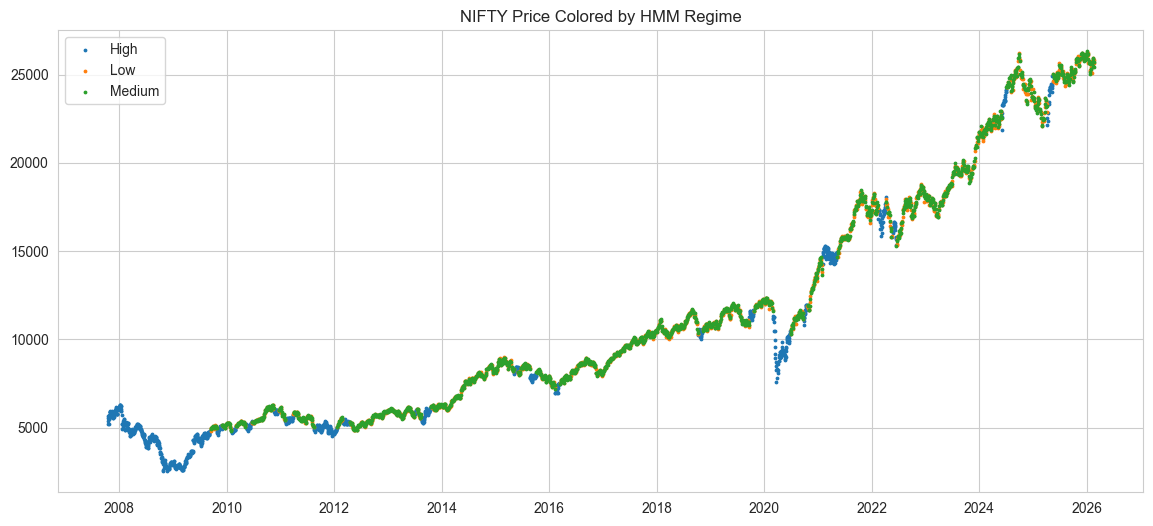

In [9]:
plt.figure(figsize=(14,6))

for regime, g in df.groupby("hmm_regime"):
    plt.scatter(g["Date"], g["Close"], s=3, label=regime)

plt.legend()
plt.title("NIFTY Price Colored by HMM Regime")
plt.show()

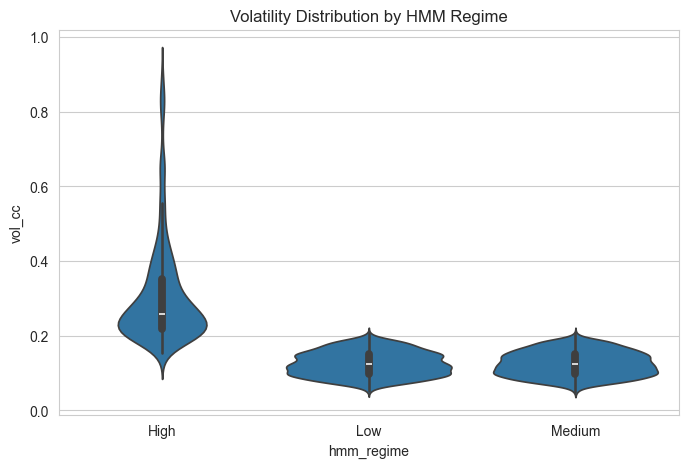

In [10]:
plt.figure(figsize=(8,5))
sns.violinplot(data=df, x="hmm_regime", y="vol_cc")
plt.title("Volatility Distribution by HMM Regime")
plt.show()

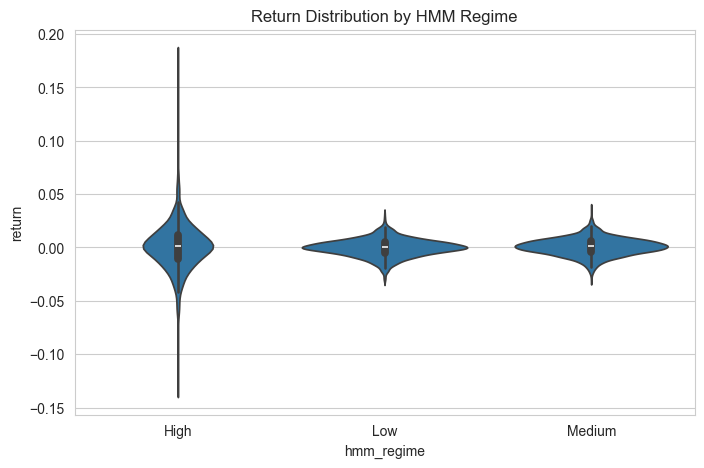

In [11]:
plt.figure(figsize=(8,5))
sns.violinplot(data=df, x="hmm_regime", y="return")
plt.title("Return Distribution by HMM Regime")
plt.show()

# **Regime Dynamics**

In [12]:
#transition matrix
trans_mat = pd.DataFrame(
    hmm.transmat_,
    index=["Low","Medium","High"],
    columns=["Low","Medium","High"]
)

trans_mat

,Low,Medium,High
Low,0.000011,0.990662,0.009327
Medium,0.996168,0.000060,0.003772
High,0.009798,0.009633,0.980570


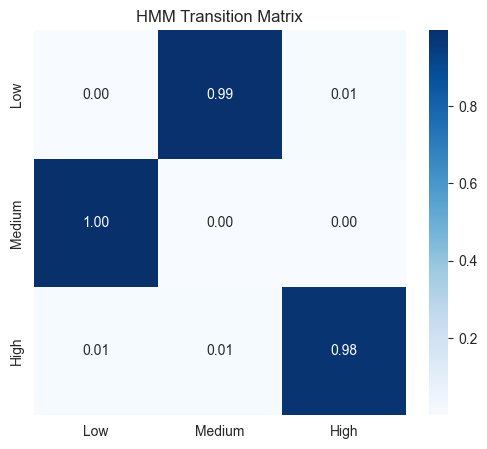

In [13]:
#transition heatmap
plt.figure(figsize=(6,5))
sns.heatmap(trans_mat, annot=True, cmap="Blues", fmt=".2f")
plt.title("HMM Transition Matrix")
plt.show()

In [14]:
#Regime duration
df["regime_change"] = df["hmm_regime"] != df["hmm_regime"].shift()

durations = df.groupby(df["regime_change"].cumsum()).size()

durations.describe()

count    3354.000000
mean        1.341980
std         8.612975
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max       467.000000
dtype: float64

# **HMM vs Quantile Regimes**

In [15]:
df_q = add_volatility_regime(df, vol_col="vol_cc")

pd.crosstab(
    df_q["vol_regime"],
    df["hmm_regime"],
    normalize="index"
)

hmm_regime,High,Low,Medium
vol_regime,,,
High,0.762745,0.121569,0.115686
Low,0.000000,0.500673,0.499327
Medium,0.001347,0.493603,0.505051


**Direction Modeling on HMM Regimes**

In [16]:
#adding direction features

df_model = df.copy()

df_model = add_target_direction(df_model)
df_model = add_lagged_returns(df_model, lags=(1,5,10))
df_model = add_moving_average_features(df_model, windows=(5,10,20))
df_model = add_volatility_features(df_model, vol_col="vol_cc", lags=(1,))

df_model = df_model.dropna().reset_index(drop=True)

In [17]:
feature_cols = [
    "ret_lag_1","ret_lag_5","ret_lag_10",
    "ma_ratio_5","ma_ratio_10","ma_ratio_20",
    "vol_cc","vol_cc_lag_1"
]

split = int(len(df_model)*0.8)

train = df_model.iloc[:split]
test  = df_model.iloc[split:]

scaler = StandardScaler()

X_train = scaler.fit_transform(train[feature_cols])
X_test  = scaler.transform(test[feature_cols])

y_train = train["target"]
y_test  = test["target"]

logit = LogisticRegression(max_iter=1000)
logit.fit(X_train, y_train)

test["pred"] = logit.predict(X_test)

In [18]:
hmm_regime_acc = test.groupby("hmm_regime").apply(
    lambda g: (g["pred"] == g["target"]).mean()
)

hmm_regime_acc

hmm_regime
High      0.613636
Low       0.563380
Medium    0.531616
dtype: float64

In [22]:
test_q = add_volatility_regime(test, vol_col="vol_cc")

quant_acc = test_q.groupby("vol_regime").apply(
    lambda g: (g["pred"] == g["target"]).mean()
)

pd.DataFrame({
    "Quantile": quant_acc,
    "HMM": hmm_regime_acc
})

,Quantile,HMM
High,0.563934,0.613636
Low,0.564189,0.563380
Medium,0.523649,0.531616


In [25]:
import os

save_dir = "../data/processed"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "hmm_regimes.csv")

df[["Date", "hmm_regime"]].to_csv(save_path, index=False)

print(f"Saved HMM regimes ->df = pd.read_csv("../data/raw/nifty50.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

df = add_returns(df)
df = add_close_to_close_volatility(df, window=20) {save_path}")

Saved HMM regimes -> ../data/processed\hmm_regimes.csv
